# Interpolación lineal.

**Objetivo general.** 

Revisar e implementar una interpolación lineal y aplicarlas a datos reales.

**Trabajo realizado con el apoyo del Programa UNAM-DGAPA-PAPIME, proyectos PE101019, PE101922 y PE106025.**

[![License: CC BY-SA 4.0](https://img.shields.io/badge/License-CC_BY--SA_4.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)

In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import macti.vis as mvis

## Introducción

Dado un conjunto de datos del estilo:

|$x$  | $f(x)$ |
|---|---|
|$x_0$|$f(x_0)$|
|$\dots$|$\dots$|
|$x_k$|$f(x_k)$|

¿Será posible encontrar $f(x)$ para $x \notin [x_0, \dots, x_k]$ ?

Por ejemplo, para los datos que se usan en el artículo:  

<img src="./figura_articulo.jpg"  style="width: 500px;" align="right"/>
<blockquote cite="https://doi.org/10.1016/j.jvolgeores.2015.09.019">
    Canet <i>et al</i>. (<b>2015</b>). Thermal history of the Acoculco geothermal system, eastern Mexico: Insights from numerical modeling and radiocarbon dating. <i>Journal of Volcanology and Geothermal Research</i>. <b>305<b>. 

[https://doi.org/10.1016/j.jvolgeores.2015.09.019](https://doi.org/10.1016/j.jvolgeores.2015.09.019)

</blockquote>


El archivo `T_inicial.csv` contiene los datos de temperatura contra profundidad. Leemos el conjunto de datos como sigue:

In [5]:
datos = pd.read_csv('T_inicial.csv')
datos

,Depth,Temp
0,0,15
1,100,113
2,200,145
3,400,178
4,710,155
5,803,201
6,1100,215
7,1200,282
8,1400,223
9,1500,226


Para entender mejor los datos vamos a graficarlos.

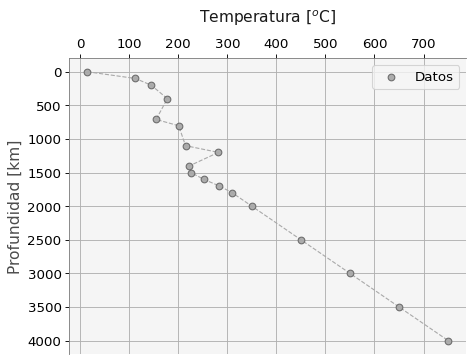

In [18]:
# Graficación de los datos 
plt.scatter(datos.Temp, datos.Depth, label='Datos',
            ec='dimgrey', fc='darkgrey', alpha=0.95, zorder=5, )
# Líneas que unen a los datos
plt.plot(datos.Temp, datos.Depth, 
         '--', color='darkgrey', lw = 1.0)

ax = plt.gca() # Obtenemos los ejes de la figura
ax.invert_yaxis() # Invertimos el eje y

# Ponemos los ticks y labels en arriba
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)

# Modificamos algunas líneas del marco.
ax.spines['top'].set_visible(True)
ax.spines['bottom'].set_visible(False)

plt.title('Temperatura [$^o$C]', loc="center", y=1.10)
plt.ylabel('Profundidad [km]')
plt.legend()
plt.grid()
plt.show()

**¿Qué interpretación le puedes dar a estos datos?**


<div class="alert alert-success">

## Ejemplo 1.

Supongamos que tenemos dos parejas de datos del tipo $(x, f(x))$ :

|$x$  | $f(x)$ |
|:-:|:-:|
|$3$|$54$|
|$5$|$123$|

¿Cual sería el valor de $f(x)$ para $x = 3.75$?

</div>

### Paso 1. Graficamos los datos.

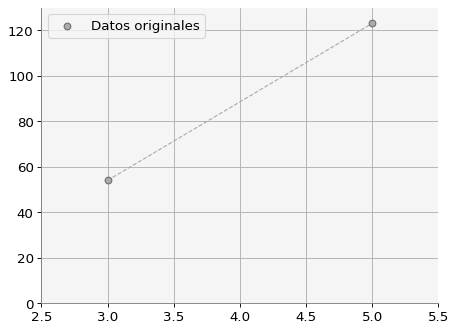

In [19]:
# Definimos los datos de la tabla
x0, f0 = 3, 54
x1, f1 = 5, 123

# Graficación de los datos 
plt.scatter([x0, x1], [f0, f1], ec='dimgray', fc='darkgray', alpha=0.95, zorder=5, 
            label='Datos originales')
# Líneas que unen a los datos
plt.plot([x0, x1], [f0, f1], '--', color='darkgray', lw = 1.0)

plt.xlim(2.5,5.5)
plt.ylim(0,130)
plt.legend()
plt.grid()
plt.show()

### Paso 2. Construcción de una función lineal.

Escribimos primero la ecuación de la recta como sigue:

$$
f(x) = m x + b \tag{1}
$$

donde la pendiente $m$ y la ordenada al origen $b$ se calculan como sigue, para dos pares de datos $(x_0, f(x_0))$ y $(x_1, f(x_1))$:

$$
m = \dfrac{f(x_1) - f(x_0)}{x_1 - x_0} \;\;\; \text{y} \;\;\; b = f(x_0) - m x_0
$$

Entonces, para realizar una interpolación lineal y encontrar $f(x)$ para $x=3.75$, usando los datos (`x0`, `f0`) y (`x1`, `f1`) definidos antes, calculamos $m$ y $b$ como sigue:

In [24]:
m = (f1 - f0) / (x1 - x0) # Pendiente
b = f0 - m * x0           # Ordenada al origen

print(f"m = {m}")
print(f"b = {b}")

m = 34.5
b = -49.5


Entonces, la ecuación de la recta $(1)$ se puede implementar como sigue:

In [25]:
S = lambda x, m, b: m * x + b

Evaluamos la ecuación de la recta en el punto $x = 3.75$ y obtenemos

In [26]:
x = 3.75
y = S(x, m, b)
print(f"Resultado de la interpolación lineal: {y}")

Resultado de la interpolación lineal: 79.875


### Paso 3. Graficamos el resultado de la interpolación.

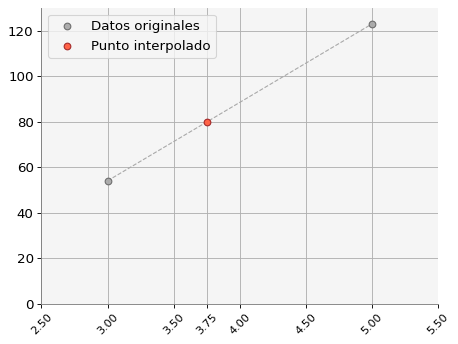

In [27]:
# Graficación de los datos 
plt.scatter([x0, x1], [f0, f1], ec='dimgray', fc='darkgray', alpha=0.95, zorder=5, 
            label='Datos originales')
# Líneas que unen a los datos
plt.plot([x0, x1], [f0, f1], '--', color='darkgray', lw = 1.0)

# Datos interpolados
plt.scatter(x, y, ec='brown', fc='tomato', zorder=5, 
            label='Punto interpolado') 

plt.xlim(2.5,5.5)
plt.ylim(0,130)
plt.xticks([2.5, 3.0, 3.5, 3.75, 4.0, 4.5, 5.0, 5.5], 
           fontsize=10, rotation=45)
plt.legend()
plt.grid()
plt.show()

<div class="alert alert-success">

## Ejemplo 2.

Realizar una interpolación lineal a un punto de los datos del artículo *Canet et al. (2015)* mostrados antes.

</div>

### Paso 1. Graficamos los datos.

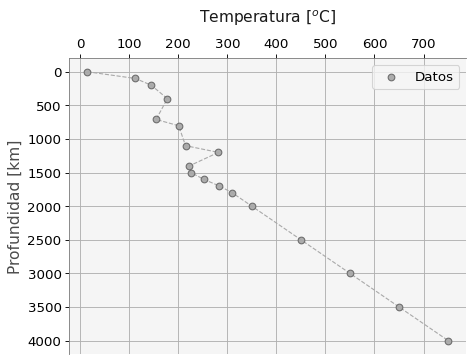

In [71]:
# Graficación de los datos 
plt.scatter(datos.Temp, datos.Depth, label='Datos',
            ec='dimgrey', fc='darkgrey', alpha=0.95, zorder=5, )
# Líneas que unen a los datos
plt.plot(datos.Temp, datos.Depth, 
         '--', color='darkgrey', lw = 1.0)

ax = plt.gca() # Obtenemos los ejes de la figura
ax.invert_yaxis() # Invertimos el eje y

# Ponemos los ticks y labels en arriba
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)

# Modificamos algunas líneas del marco.
ax.spines['top'].set_visible(True)
ax.spines['bottom'].set_visible(False)

plt.title('Temperatura [$^o$C]', loc="center", y=1.10)
plt.ylabel('Profundidad [km]')
plt.legend()
plt.grid()
plt.show()

### Paso 2. Construcción de la función lineal.

Primero vamos a seleccionar dos pares de datos.

In [32]:
datos.iloc[13:15]

,Depth,Temp
13,2000,350
14,2500,450


Con estos datos haremos una interpolación lineal entre una profundidad de $2000$ y $2500$ metros. Por ejemplo en el punto medio $2250$.

In [33]:
# Obtenemos los datos del DataFrame
x0, f0 = datos.iloc[13,0], datos.iloc[13,1]
x1, f1 = datos.iloc[14,0], datos.iloc[14,1]

m = (f1 - f0) / (x1 - x0) # Pendiente
b = f0 - m * x0           # Ordenada al origen

# Aplicamos la interpolación en el punto requerido.
xj = (x0 + x1) * 0.5 # Punto medio entre x0 y x1
yj = S(xj, m, b)
print(f"Resultado de la interpolación: {yj}")

Resultado de la interpolación: 400.0


### Paso 3. Graficamos el resultado de la interpolación.

In [41]:
print(xj)

2250.0


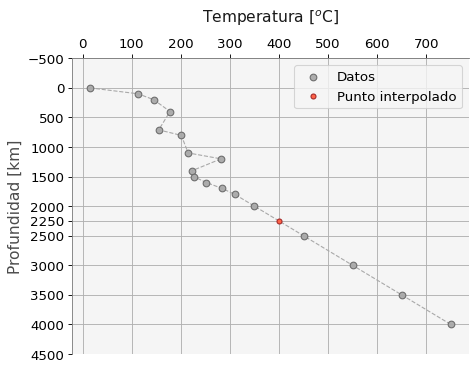

In [67]:
# Graficación de los datos 
plt.scatter(datos.Temp, datos.Depth, label='Datos',
            ec='dimgrey', fc='darkgrey', alpha=0.95, zorder=5, )
# Líneas que unen a los datos
plt.plot(datos.Temp, datos.Depth, 
         '--', color='darkgrey', lw = 1.0)

# Datos interpolados
plt.scatter(yj, xj, ec='brown', fc='tomato', s = 20, zorder=5, 
            label='Punto interpolado') 

ax = plt.gca() # Obtenemos los ejes de la figura
ax.invert_yaxis() # Invertimos el eje y

# Ponemos los ticks y labels en arriba
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)

# Modificamos algunas líneas del marco.
ax.spines['top'].set_visible(True)
ax.spines['bottom'].set_visible(False)

# Agregamos la marca del punto de interpolación en el eje y.
yticks = ax.get_yticks()
yticks = np.append(yticks, xj)
ax.set_yticks(yticks)

plt.title('Temperatura [$^o$C]', loc="center", y=1.10)
plt.ylabel('Profundidad [km]')
plt.legend()
plt.grid()
plt.show()

<div class="alert alert-success">

## Ejemplo 3.

Aplicar la interpolación **lineal** a los datos de *Canet et al. (2015)* para conocer la temperatura en 100 puntos de profundidad igualmente espaciados desde $0$ a $4000$ metros.

</div>

### Paso 1. Interpolaciones en cada intervalo.

Para realizar este ejemplo podemos interpolar linealmente entre cada par de datos. Para ello es conveniente construir una función que genere todas las funciones lineales entre cada para puntos. Esta función se muestra en la siguiente celda.

In [57]:
def lineal(x, f, z):
    """
    Parameters.
    x: Arreglo de datos
    f: Arreglo de datos correspondientes con el arreglo x
    z: Arreglo de datos donde se desea interpolar.

    Returns.
    y: Puntos interpolados.
    """
    k = len(x)-1  # Número de intervalos 
    m = np.zeros(k) # Arreglo para las pendientes

    # Cálculo de las pendientes de cada intervalo
    for i in range(k):
        m[i] = (f[i + 1] - f[i]) / (x[i + 1] - x[i]) 

    # Arreglo para almacenar la interpolación
    y = np.zeros_like(z)

    # Recorremos todos los datos z
    for j, xj in enumerate(z): 
        # Por cada intervalo se hace la interpolación lineal
        for i in range(k):
            if xj >= x[i] and xj <= x[i + 1]: # Si el dato cae en el intervalo, entonces
                # Calcular la interpolación lineal
                y[j] = S(xj, m[i], f[i] - x[i] * m[i]) 
                break
    return y # Regresamos las interpolaciones

### Paso 2. Generar las profundidades requeridas.

Generamos los datos de profundidades donde se requiere hacer la interpolación para obtener la temperatura.

In [78]:
L = max(datos.Depth)        # Profundidad máxima
N = 99                      # Número de incógnitas (usamos 99 por conveniencia)
z = np.linspace(0, L, N+2)  # Coordenada z de la profundidad

print(len(z))
print(z)

101
[   0.   40.   80.  120.  160.  200.  240.  280.  320.  360.  400.  440.
  480.  520.  560.  600.  640.  680.  720.  760.  800.  840.  880.  920.
  960. 1000. 1040. 1080. 1120. 1160. 1200. 1240. 1280. 1320. 1360. 1400.
 1440. 1480. 1520. 1560. 1600. 1640. 1680. 1720. 1760. 1800. 1840. 1880.
 1920. 1960. 2000. 2040. 2080. 2120. 2160. 2200. 2240. 2280. 2320. 2360.
 2400. 2440. 2480. 2520. 2560. 2600. 2640. 2680. 2720. 2760. 2800. 2840.
 2880. 2920. 2960. 3000. 3040. 3080. 3120. 3160. 3200. 3240. 3280. 3320.
 3360. 3400. 3440. 3480. 3520. 3560. 3600. 3640. 3680. 3720. 3760. 3800.
 3840. 3880. 3920. 3960. 4000.]


### Paso 3. Realizar la interpolación. 

In [75]:
yint= lineal(datos.Depth, datos.Temp, z) # Interpolación lineal

El arreglo `yint` contiene los datos de las temperaturas interpoladas.

In [76]:
print(yint)

[ 15.          54.2         93.4        119.4        132.2
 145.         151.6        158.2        164.8        171.4
 178.         175.03225806 172.06451613 169.09677419 166.12903226
 163.16129032 160.19354839 157.22580645 159.94623656 179.7311828
 199.51612903 202.74410774 204.62962963 206.51515152 208.4006734
 210.28619529 212.17171717 214.05723906 228.4        255.2
 282.         270.2        258.4        246.6        234.8
 223.         224.2        225.4        231.2        241.6
 252.         264.8        277.6        289.2        299.6
 310.         318.         326.         334.         342.
 350.         358.         366.         374.         382.
 390.         398.         406.         414.         422.
 430.         438.         446.         454.         462.
 470.         478.         486.         494.         502.
 510.         518.         526.         534.         542.
 550.         558.         566.         574.         582.
 590.         598.         606.         614.

### Paso 4. Graficamos los datos reales y los interpolados:

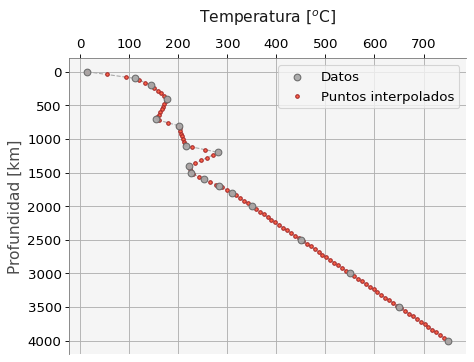

In [77]:
# Graficación de los datos 
plt.scatter(datos.Temp, datos.Depth, label='Datos',
            ec='dimgrey', fc='darkgrey', alpha=0.95, zorder=5, )
# Líneas que unen a los datos
plt.plot(datos.Temp, datos.Depth, 
         '--', color='darkgrey', lw = 1.0)

# Datos interpolados
plt.scatter(yint, z, ec='brown', fc='tomato', s = 10, zorder=3, 
            label='Puntos interpolados') 

ax = plt.gca() # Obtenemos los ejes de la figura
ax.invert_yaxis() # Invertimos el eje y

# Ponemos los ticks y labels en arriba
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)

# Modificamos algunas líneas del marco.
ax.spines['top'].set_visible(True)
ax.spines['bottom'].set_visible(False)

plt.title('Temperatura [$^o$C]', loc="center", y=1.10)
plt.ylabel('Profundidad [km]')
plt.legend()
plt.grid()
plt.show()

Con base en este resultado:

* ¿Qué opinas de esta interpolación?
* ¿Es correcta numéricamente?
* ¿Reproduce la realidad?
* ¿La usarías en algún proyecto? ¿Por qué?
* ¿Cómo podrías mejorar esta interpolación?